SOLAR PENETRATION SCENARIOS
==============================
Creates daily penetration index scenario dataframes for 2026–2050
based on three policy/market trajectories for Italy NORD zone.
 
Penetration index = solar_share_pct / REFERENCE_SHARE
where REFERENCE_SHARE = 13.00% (peak observed in 2025, from GSE/Terna)
 
Current solar share (2025): 13.00% → pen = 13.00/13.00 = 1.000
 
Scenarios (solar share of national electricity consumption by 2050):
  Scenario A — Current Trend (Extrapolated)  : 30%  → pen = 2.308
               Extrapolation of 2019–2025 growth rate (~1.2%/yr share gain)
               Conservative baseline: no policy acceleration
 
  Scenario B — PNIEC 2024 (Italy NECP)       : 45%  → pen = 3.462
               Aligned with Italy's updated National Energy and Climate Plan
               (PNIEC July 2024): 80 GW PV by 2030 (~24% share),
               scaling to 45% by 2050 via net-zero pathway.
               Source: MASE PNIEC 2024; IEA-PVPS Italy 2024 NSR.
 
  Scenario C — ENTSO-E Distributed Energy    : 60%  → pen = 4.615
               Based on ENTSO-E TYNDP 2024 "Distributed Energy" scenario,
               high electrification with massive decentralised solar.
               Upper bound: aggressive buildout consistent with 1.5°C pathway.
 
All scenarios:
  - Start from pen(2026) = 1.000 (continuity with 2025 observed — at reference)
  - Use logistic growth calibrated to hit scenario-specific 2030 waypoints
    and 2050 targets
  - Are expressed as daily values for direct use in reconstruction notebook
 
Output: Data/Cleaned/df_penetration_scenarios.parquet
        columns: date, year, month, doy, decimal_year,
                 pen_current_trend, pen_pniec, pen_entso_e,
                 solar_share_current_trend, solar_share_pniec,
                 solar_share_entso_e

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

In [156]:
# ── paths ─────────────────────────────────────────────────────────────────────
data_cleaned = Path("../../Data/Cleaned")
data_cleaned.mkdir(parents=True, exist_ok=True)

In [157]:
# ── simulation horizon ────────────────────────────────────────────────────────
START_DATE = "2026-01-01"
END_DATE   = "2050-12-31"
 
dates_pd   = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
decimal_yr = (dates_pd.year + (dates_pd.dayofyear - 1) / 365.0).values

In [158]:
# load solar share from cleaned data
df_solar_share  = pd.read_parquet(
    data_cleaned / "df_solar_share.parquet"
)
solar_share_hist = dict(zip(
    df_solar_share["year"],
    df_solar_share["solar_share_pct"]
))

# add 2025 if not already present
if 2025 not in solar_share_hist:
    solar_share_hist[2025] = 13.00
    print(f"  2025 added manually: 13.00%")

# reference share = maximum observed (peak year)
REFERENCE_SHARE  = float(max(solar_share_hist.values()))
REFERENCE_YEAR   = int(max(solar_share_hist, key=solar_share_hist.get))

print(f"  Loaded {len(solar_share_hist)} years from df_solar_share.parquet")
print(f"  Years  : {min(solar_share_hist)} – {max(solar_share_hist)}")
print(f"  REFERENCE_SHARE : {REFERENCE_SHARE}%  "
      f"(peak year = {REFERENCE_YEAR})")

# anchor penetration index in 2026 — last observed year
last_year        = max(solar_share_hist)
PEN_2026         = solar_share_hist[last_year] / REFERENCE_SHARE
print(f"  pen(2026) anchor: {PEN_2026:.4f}  "
      f"({last_year} share = {solar_share_hist[last_year]}%)")

  Loaded 21 years from df_solar_share.parquet
  Years  : 2005 – 2025
  REFERENCE_SHARE : 13.0%  (peak year = 2025)
  pen(2026) anchor: 1.0000  (2025 share = 13.0%)


In [159]:

# GOMPERTZ GROWTH FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
# pen(t) = lo + (hi - lo) * exp(-exp(-k * (t - t_mid)))
#
# Unlike the symmetric logistic, Gompertz has a slow early start and faster
# approach to the upper asymptote — more realistic for technology adoption.
# Inflection point at t_mid where pen = lo + (hi - lo) / e  (~36.8% of range)
#
# Asymptotes:
#   hi = pen_target_2050 * 1.05   (5% headroom — allows later t_mid, smaller k)
#   lo = pen_start * 0.80         (slightly below start for upward curvature)
#
# Calibration targets (both weighted 1e12):
#   pen(year_start) = pen_start
#   pen(year_end)   = pen_target_2050
#
# Smoothness penalty: (k**2) * 100

from scipy.optimize import minimize

def gompertz(t, t_mid, k, lo, hi):
    return lo + (hi - lo) * np.exp(-np.exp(-k * (t - t_mid)))


def calibrate_gompertz(pen_start, pen_target_2050,
                       year_start=2026, year_end=2050):
    """
    Calibrate Gompertz growth so that:
      pen(year_start) = pen_start        [hard boundary, weight 1e12]
      pen(year_end)   = pen_target_2050  [hard boundary, weight 1e12]
    hi is set 5% above target so the optimizer can find a later t_mid
    and smaller k while still hitting the 2050 value exactly.
    Returns (lo, hi, k_opt, tmid_opt).
    """
    hi = pen_target_2050 * 1.05   # 5% headroom — allows later t_mid and smaller k
    lo = pen_start * 0.9        # lower asymptote slightly below start

    def gompertz_pred(t, k, t_mid):
        return lo + (hi - lo) * np.exp(-np.exp(-k * (t - t_mid)))

    def residuals(params):
        k, t_mid = params
        if k <= 0.005:
            return 1e15
        r_start = (gompertz_pred(year_start, k, t_mid) - pen_start)       ** 2
        r_end   = (gompertz_pred(year_end,   k, t_mid) - pen_target_2050) ** 2
        smooth  = (k ** 2) * 100
        return r_start * 1e12 + r_end * 1e12 + smooth

    # grid search — with headroom t_mid can sit further into the horizon
    best_res = np.inf
    best_x0  = [0.1, 2037.0]
    for k0 in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
        for tm0 in [2030, 2033, 2036, 2039, 2042, 2045]:
            r = residuals([k0, tm0])
            if r < best_res:
                best_res = r
                best_x0  = [k0, tm0]

    result = minimize(
        residuals, best_x0,
        method="Nelder-Mead",
        options={"maxiter": 100_000, "xatol": 1e-10, "fatol": 1e-12}
    )
    k_opt, tmid_opt = result.x

    # boundary check
    err_start = abs(gompertz_pred(year_start, k_opt, tmid_opt) - pen_start)
    err_end   = abs(gompertz_pred(year_end,   k_opt, tmid_opt) - pen_target_2050)
    if err_start > 1e-3 or err_end > 1e-3:
        print(f"  ⚠  boundary residuals: start={err_start:.2e}  end={err_end:.2e}")

    return lo, hi, float(k_opt), float(tmid_opt)


In [160]:

# SCENARIO A — Current Trend Extrapolated (30% by 2050)
# ─────────────────────────────────────────────────────────────────────────────
TARGET_A_2050 = 30.0
PEN_A_2050    = TARGET_A_2050 / REFERENCE_SHARE

lo_a, hi_a, k_a, tmid_a = calibrate_gompertz(PEN_2026, PEN_A_2050)
pen_a = gompertz(decimal_yr, tmid_a, k_a, lo_a, hi_a)

print(f"  Scenario A: k={k_a:.4f}  t_mid={tmid_a:.2f}  "
      f"pen(2026)={gompertz(2026, tmid_a, k_a, lo_a, hi_a):.4f}  "
      f"pen(2050)={gompertz(2050, tmid_a, k_a, lo_a, hi_a):.4f}  "
      f"(target={PEN_A_2050:.4f})")


  Scenario A: k=0.1476  t_mid=2032.79  pen(2026)=1.0000  pen(2050)=2.3077  (target=2.3077)


In [161]:

# SCENARIO B — PNIEC 2024 (45% by 2050)
# ─────────────────────────────────────────────────────────────────────────────
TARGET_B_2050 = 45.0
PEN_B_2050    = TARGET_B_2050 / REFERENCE_SHARE

lo_b, hi_b, k_b, tmid_b = calibrate_gompertz(PEN_2026, PEN_B_2050)
pen_b = gompertz(decimal_yr, tmid_b, k_b, lo_b, hi_b)

print(f"  Scenario B: k={k_b:.4f}  t_mid={tmid_b:.2f}  "
      f"pen(2026)={gompertz(2026, tmid_b, k_b, lo_b, hi_b):.4f}  "
      f"pen(2050)={gompertz(2050, tmid_b, k_b, lo_b, hi_b):.4f}  "
      f"(target={PEN_B_2050:.4f})")


  Scenario B: k=0.1635  t_mid=2033.32  pen(2026)=1.0000  pen(2050)=3.4615  (target=3.4615)


In [162]:

# SCENARIO C — ENTSO-E Distributed Energy (60% by 2050)
# ─────────────────────────────────────────────────────────────────────────────
TARGET_C_2050 = 60.0
PEN_C_2050    = TARGET_C_2050 / REFERENCE_SHARE

lo_c, hi_c, k_c, tmid_c = calibrate_gompertz(PEN_2026, PEN_C_2050)
pen_c = gompertz(decimal_yr, tmid_c, k_c, lo_c, hi_c)

print(f"  Scenario C: k={k_c:.4f}  t_mid={tmid_c:.2f}  "
      f"pen(2026)={gompertz(2026, tmid_c, k_c, lo_c, hi_c):.4f}  "
      f"pen(2050)={gompertz(2050, tmid_c, k_c, lo_c, hi_c):.4f}  "
      f"(target={PEN_C_2050:.4f})")


  Scenario C: k=0.1713  t_mid=2033.60  pen(2026)=1.0000  pen(2050)=4.6154  (target=4.6154)


In [163]:
# BUILD OUTPUT DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────
df_scenarios = pd.DataFrame({
    "date":                    dates_pd,
    "year":                    dates_pd.year,
    "month":                   dates_pd.month,
    "doy":                     dates_pd.dayofyear,
    "decimal_year":            decimal_yr,
    # penetration index (normalised to REFERENCE_SHARE)
    "pen_current_trend":       pen_a,
    "pen_pniec":               pen_b,
    "pen_entso_e":             pen_c,
    # implied solar share %
    "solar_share_current_trend": pen_a * REFERENCE_SHARE,
    "solar_share_pniec":         pen_b * REFERENCE_SHARE,
    "solar_share_entso_e":       pen_c * REFERENCE_SHARE,
})

In [164]:

# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n── Gompertz calibration parameters ──────────────────────────────")
print(f"  {'Scenario':<22}  {'lo':>6}  {'hi':>6}  {'k':>7}  {'t_mid':>7}  "
      f"{'pen(2026)':>10}  {'pen(2050)':>10}  {'target 2050':>12}")
print(f"  {'-'*22}  {'-'*6}  {'-'*6}  {'-'*7}  {'-'*7}  "
      f"{'-'*10}  {'-'*10}  {'-'*12}")
for name, lo, hi, k, tmid, target in [
    ("Current Trend (30%)", lo_a, hi_a, k_a, tmid_a, TARGET_A_2050),
    ("PNIEC 2024   (45%)", lo_b, hi_b, k_b, tmid_b, TARGET_B_2050),
    ("ENTSO-E DE   (60%)", lo_c, hi_c, k_c, tmid_c, TARGET_C_2050),
]:
    p26 = gompertz(2026, tmid, k, lo, hi)
    p50 = gompertz(2050, tmid, k, lo, hi)
    print(f"  {name:<22}  {lo:>6.3f}  {hi:>6.3f}  {k:>7.4f}  {tmid:>7.2f}  "
          f"{p26:>10.4f}  {p50:>10.4f}  {target:>11.1f}%")

print(f"\n── Penetration index by year ─────────────────────────────────────")
print(f"  {'Year':>6}  {'pen_A (30%)':>12}  {'share_A':>8}  "
      f"{'pen_B (45%)':>12}  {'share_B':>8}  "
      f"{'pen_C (60%)':>12}  {'share_C':>8}")
print(f"  {'-'*6}  {'-'*12}  {'-'*8}  "
      f"{'-'*12}  {'-'*8}  "
      f"{'-'*12}  {'-'*8}")
for yr in [2026, 2028, 2030, 2035, 2040, 2045, 2050]:
    m  = df_scenarios["year"] == yr
    pa = df_scenarios.loc[m, "pen_current_trend"].mean()
    pb = df_scenarios.loc[m, "pen_pniec"].mean()
    pc = df_scenarios.loc[m, "pen_entso_e"].mean()
    print(f"  {yr:>6}  {pa:>12.4f}  "
          f"{pa*REFERENCE_SHARE:>7.1f}%  "
          f"{pb:>12.4f}  "
          f"{pb*REFERENCE_SHARE:>7.1f}%  "
          f"{pc:>12.4f}  "
          f"{pc*REFERENCE_SHARE:>7.1f}%")



── Gompertz calibration parameters ──────────────────────────────
  Scenario                    lo      hi        k    t_mid   pen(2026)   pen(2050)   target 2050
  ----------------------  ------  ------  -------  -------  ----------  ----------  ------------
  Current Trend (30%)      0.900   2.423   0.1476  2032.79      1.0000      2.3077         30.0%
  PNIEC 2024   (45%)       0.900   3.635   0.1635  2033.32      1.0000      3.4615         45.0%
  ENTSO-E DE   (60%)       0.900   4.846   0.1713  2033.60      1.0000      4.6154         60.0%

── Penetration index by year ─────────────────────────────────────
    Year   pen_A (30%)   share_A   pen_B (45%)   share_B   pen_C (60%)   share_C
  ------  ------------  --------  ------------  --------  ------------  --------
    2026        1.0217     13.3%        1.0305     13.4%        1.0364     13.5%
    2028        1.1321     14.7%        1.2044     15.7%        1.2612     16.4%
    2030        1.2751     16.6%        1.4607     19.0%

In [165]:

# BOUNDARY VALIDATION
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n── Boundary validation (2026 / 2050) ────────────────────────────")
print(f"  {'Scenario':<22}  {'pen(2026)':>10}  {'target 2026':>12}  "
      f"{'pen(2050)':>10}  {'target 2050':>12}  {'status'}")
print(f"  {'-'*22}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*12}  {'-'*6}")
for name, lo, hi, k, tmid, target_2050 in [
    ("Current Trend (30%)", lo_a, hi_a, k_a, tmid_a, PEN_A_2050),
    ("PNIEC 2024   (45%)", lo_b, hi_b, k_b, tmid_b, PEN_B_2050),
    ("ENTSO-E DE   (60%)", lo_c, hi_c, k_c, tmid_c, PEN_C_2050),
]:
    p26 = gompertz(2026, tmid, k, lo, hi)
    p50 = gompertz(2050, tmid, k, lo, hi)
    ok  = abs(p26 - PEN_2026) < 1e-3 and abs(p50 - target_2050) < 1e-3
    print(f"  {name:<22}  {p26:>10.4f}  {PEN_2026:>12.4f}  "
          f"{p50:>10.4f}  {target_2050:>12.4f}  "
          f"{'✓' if ok else '✗ check'}")



── Boundary validation (2026 / 2050) ────────────────────────────
  Scenario                 pen(2026)   target 2026   pen(2050)   target 2050  status
  ----------------------  ----------  ------------  ----------  ------------  ------
  Current Trend (30%)         1.0000        1.0000      2.3077        2.3077  ✓
  PNIEC 2024   (45%)          1.0000        1.0000      3.4615        3.4615  ✓
  ENTSO-E DE   (60%)          1.0000        1.0000      4.6154        4.6154  ✓


In [166]:
# SAVE
# ─────────────────────────────────────────────────────────────────────────────
out_path = data_cleaned / "df_penetration_scenarios.parquet"
df_scenarios.to_parquet(out_path, index=False, compression="snappy")
print(f"\n  Saved : {out_path}")
print(f"  Rows  : {len(df_scenarios):,}")
print(f"  Cols  : {list(df_scenarios.columns)}")


  Saved : ..\..\Data\Cleaned\df_penetration_scenarios.parquet
  Rows  : 9,131
  Cols  : ['date', 'year', 'month', 'doy', 'decimal_year', 'pen_current_trend', 'pen_pniec', 'pen_entso_e', 'solar_share_current_trend', 'solar_share_pniec', 'solar_share_entso_e']


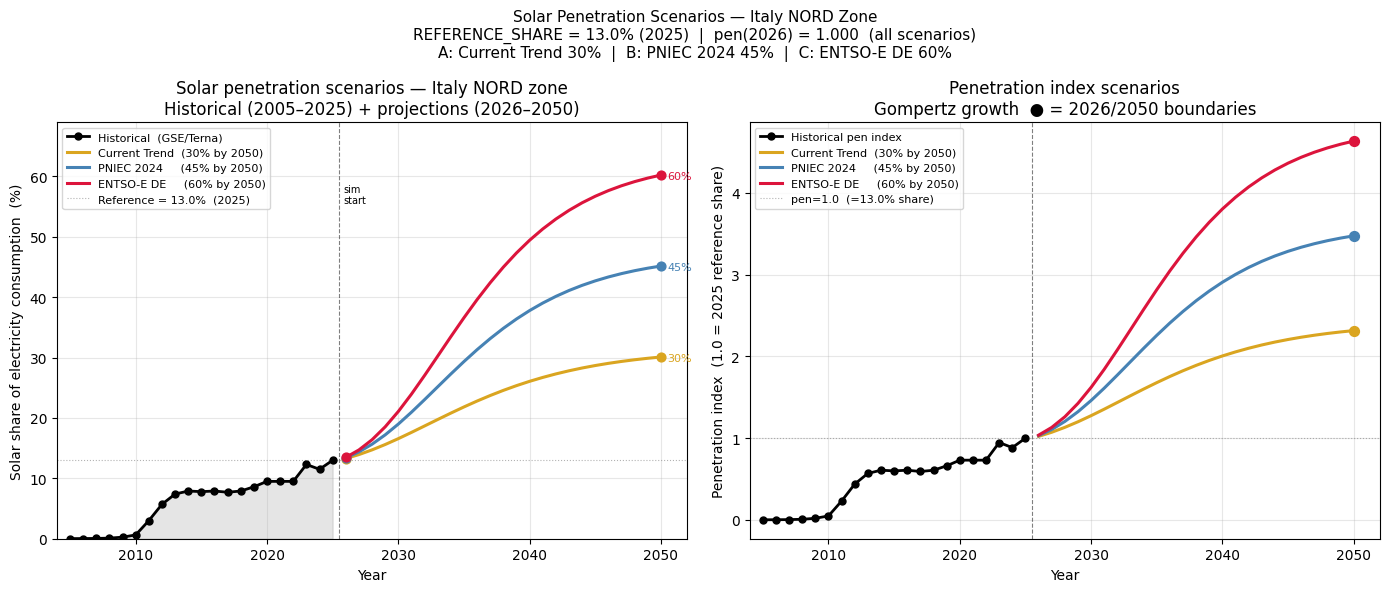

In [167]:
 #PLOTS
# ─────────────────────────────────────────────────────────────────────────────
hist_years  = np.array(sorted(solar_share_hist.keys()))
hist_shares = np.array([solar_share_hist[y] for y in hist_years])
hist_pen    = hist_shares / REFERENCE_SHARE

ann = df_scenarios.groupby("year")[
    ["pen_current_trend", "pen_pniec", "pen_entso_e",
     "solar_share_current_trend", "solar_share_pniec",
     "solar_share_entso_e"]
].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

COLORS = {
    "current_trend": "goldenrod",
    "pniec":         "steelblue",
    "entso_e":       "crimson",
}
LABELS = {
    "current_trend": f"Current Trend  ({TARGET_A_2050:.0f}% by 2050)",
    "pniec":         f"PNIEC 2024     ({TARGET_B_2050:.0f}% by 2050)",
    "entso_e":       f"ENTSO-E DE     ({TARGET_C_2050:.0f}% by 2050)",
}

# ── left: solar share % ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(hist_years, hist_shares, "o-",
        color="black", lw=2.0, ms=5, zorder=5,
        label="Historical  (GSE/Terna)")
ax.fill_between(hist_years, hist_shares, alpha=0.10, color="black")

for key, col in [("current_trend", "solar_share_current_trend"),
                  ("pniec",         "solar_share_pniec"),
                  ("entso_e",       "solar_share_entso_e")]:
    ax.plot(ann["year"], ann[col], "-",
            color=COLORS[key], lw=2.2, label=LABELS[key])
    for yr in [2026, 2050]:
        val = ann.loc[ann["year"] == yr, col].values[0]
        ax.scatter([yr], [val], color=COLORS[key], s=40, zorder=5)

for key, target in [("current_trend", TARGET_A_2050),
                     ("pniec",         TARGET_B_2050),
                     ("entso_e",       TARGET_C_2050)]:
    ax.annotate(f"{target:.0f}%",
                xy=(2050, target),
                xytext=(2050.5, target),
                fontsize=8, color=COLORS[key], va="center")

ax.axvline(2025.5, color="black", lw=0.8, ls="--", alpha=0.5)
ax.text(2025.8, TARGET_C_2050 * 0.98, "sim\nstart", fontsize=7, va="top")
ax.axhline(REFERENCE_SHARE, color="grey", lw=0.8, ls=":",
           alpha=0.6, label=f"Reference = {REFERENCE_SHARE}%  (2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Solar share of electricity consumption  (%)")
ax.set_title("Solar penetration scenarios — Italy NORD zone\n"
             "Historical (2005–2025) + projections (2026–2050)")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(2004, 2052)
ax.set_ylim(0, TARGET_C_2050 * 1.15)
ax.grid(alpha=0.3)

# ── right: penetration index ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(hist_years, hist_pen, "o-",
        color="black", lw=2.0, ms=5, zorder=5,
        label="Historical pen index")

for key, col in [("current_trend", "pen_current_trend"),
                  ("pniec",         "pen_pniec"),
                  ("entso_e",       "pen_entso_e")]:
    ax.plot(ann["year"], ann[col], "-",
            color=COLORS[key], lw=2.2, label=LABELS[key])
    val_2050 = ann.loc[ann["year"] == 2050, col].values[0]
    ax.scatter([2050], [val_2050], color=COLORS[key], s=50, zorder=5)

ax.axhline(1.0, color="grey", lw=0.8, ls=":",
           alpha=0.6, label=f"pen=1.0  (={REFERENCE_SHARE}% share)")
ax.axvline(2025.5, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Penetration index  (1.0 = 2025 reference share)")
ax.set_title("Penetration index scenarios\n"
             "Gompertz growth  ● = 2026/2050 boundaries")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(2004, 2052)
ax.grid(alpha=0.3)

plt.suptitle(
    f"Solar Penetration Scenarios — Italy NORD Zone\n"
    f"REFERENCE_SHARE = {REFERENCE_SHARE}% (2025)  |  "
    f"pen(2026) = {PEN_2026:.3f}  (all scenarios)\n"
    f"A: Current Trend {TARGET_A_2050:.0f}%  |  "
    f"B: PNIEC 2024 {TARGET_B_2050:.0f}%  |  "
    f"C: ENTSO-E DE {TARGET_C_2050:.0f}%",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [168]:
# GOMPERTZ PARAMETERS SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("── Gompertz curve parameters ────────────────────────────────────────")
print(f"  {'Scenario':<24}  {'lo':>6}  {'hi':>6}  {'k':>7}  {'t_mid':>7}  "
      f"{'pen(2026)':>10}  {'pen(2030)':>10}  {'pen(2040)':>10}  {'pen(2050)':>10}")
print(f"  {'-'*24}  {'-'*6}  {'-'*6}  {'-'*7}  {'-'*7}  "
      f"{'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}")

for name, lo, hi, k, tmid, target in [
    ("Current Trend (30%)", lo_a, hi_a, k_a, tmid_a, TARGET_A_2050),
    ("PNIEC 2024   (45%)", lo_b, hi_b, k_b, tmid_b, TARGET_B_2050),
    ("ENTSO-E DE   (60%)", lo_c, hi_c, k_c, tmid_c, TARGET_C_2050),
]:
    p26 = gompertz(2026, tmid, k, lo, hi)
    p30 = gompertz(2030, tmid, k, lo, hi)
    p40 = gompertz(2040, tmid, k, lo, hi)
    p50 = gompertz(2050, tmid, k, lo, hi)
    print(f"  {name:<24}  {lo:>6.3f}  {hi:>6.3f}  {k:>7.4f}  {tmid:>7.2f}  "
          f"{p26:>10.4f}  {p30:>10.4f}  {p40:>10.4f}  {p50:>10.4f}")

print(f"\n  Notes:")
print(f"  · hi = pen_target_2050 × 1.05  (5% headroom above 2050 target)")
print(f"  · lo = pen_start × 0.90        (lower asymptote below 2026 anchor)")
print(f"  · t_mid = inflection year      (pen = lo + (hi−lo)/e ≈ 36.8% of range)")
print(f"  · k = growth rate              (smaller → more gradual curve)")

── Gompertz curve parameters ────────────────────────────────────────
  Scenario                      lo      hi        k    t_mid   pen(2026)   pen(2030)   pen(2040)   pen(2050)
  ------------------------  ------  ------  -------  -------  ----------  ----------  ----------  ----------
  Current Trend (30%)        0.900   2.423   0.1476  2032.79      1.0000      1.2368      1.9789      2.3077
  PNIEC 2024   (45%)         0.900   3.635   0.1635  2033.32      1.0000      1.3895      2.8554      3.4615
  ENTSO-E DE   (60%)         0.900   4.846   0.1713  2033.60      1.0000      1.5190      3.7254      4.6154

  Notes:
  · hi = pen_target_2050 × 1.05  (5% headroom above 2050 target)
  · lo = pen_start × 0.90        (lower asymptote below 2026 anchor)
  · t_mid = inflection year      (pen = lo + (hi−lo)/e ≈ 36.8% of range)
  · k = growth rate              (smaller → more gradual curve)
